In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [2]:
movies_df = pd.read_csv('../data/movie.metadata.tsv', sep='\t', header=None)
characters_df = pd.read_csv('../data/character.metadata.tsv', sep='\t', header=None)
plot_summaries_df = pd.read_csv('../data/plot_summaries.txt', sep='\t', header=None)
names_df = pd.read_csv('../data/name.clusters.txt', sep='\t', header=None)



movies_df.columns = ['wikipedia_id', 'freebase_id', 'name', 'release_date', 'revenue', 'runtime', 'languages', 'countries', 'genres']

characters_df.columns = ['wikipedia_id', 'freebase_id', 'release_date', 'character_name', 'actor_date_of_birth', 
                         'actor_gender', 'actor_height', 'actor_ethnicity', 'actor_name', 'actor_age_at_movie_release',
                         'freebase_character_actor_map_id', 'freebase_character_id', 'freebase_actor_id']

plot_summaries_df.columns = ['wikipedia_id', 'plot_summary']

names_df.columns = ['character_name', 'freebase_id']

In [3]:
def extract_data(genre_string):
    # Safely evaluate the string to a dictionary
    genre_dict = ast.literal_eval(genre_string)
    # Extract only the values (genre names) and return as a list
    return list(genre_dict.values())

movies_df = movies_df.dropna(subset=['release_date'])
movies_df['genres'] = movies_df['genres'].apply(extract_data)
movies_df['languages'] = movies_df['languages'].apply(extract_data)
movies_df['countries'] = movies_df['countries'].apply(extract_data)
# keep only the year of the release date (4 first characters)
movies_df['release_date'] = movies_df['release_date'].astype(str).apply(lambda x: x[:4]).astype(int)
movies_df.head()

,wikipedia_id,freebase_id,name,release_date,revenue,runtime,languages,countries,genres
0,975900,/m/03vyhn,Ghosts of Mars,2001,14010832.0,98.0,[English Language],[United States of America],"[Thriller, Science Fiction, Horror, Adventure,..."
1,3196793,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...,2000,NaN,95.0,[English Language],[United States of America],"[Mystery, Biographical film, Drama, Crime Drama]"
2,28463795,/m/0crgdbh,Brun bitter,1988,NaN,83.0,[Norwegian Language],[Norway],"[Crime Fiction, Drama]"
3,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,[English Language],[United Kingdom],"[Thriller, Erotic thriller, Psychological thri..."
4,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,[German Language],[Germany],[Drama]


In [4]:
characters_df.head()

,wikipedia_id,freebase_id,release_date,character_name,actor_date_of_birth,actor_gender,actor_height,actor_ethnicity,actor_name,actor_age_at_movie_release,freebase_character_actor_map_id,freebase_character_id,freebase_actor_id
0,975900,/m/03vyhn,2001-08-24,Akooshay,1958-08-26,F,1.620,NaN,Wanda De Jesus,42.0,/m/0bgchxw,/m/0bgcj3x,/m/03wcfv7
1,975900,/m/03vyhn,2001-08-24,Lieutenant Melanie Ballard,1974-08-15,F,1.780,/m/044038p,Natasha Henstridge,27.0,/m/0jys3m,/m/0bgchn4,/m/0346l4
2,975900,/m/03vyhn,2001-08-24,Desolation Williams,1969-06-15,M,1.727,/m/0x67,Ice Cube,32.0,/m/0jys3g,/m/0bgchn_,/m/01vw26l
3,975900,/m/03vyhn,2001-08-24,Sgt Jericho Butler,1967-09-12,M,1.750,NaN,Jason Statham,33.0,/m/02vchl6,/m/0bgchnq,/m/034hyc
4,975900,/m/03vyhn,2001-08-24,Bashira Kincaid,1977-09-25,F,1.650,NaN,Clea DuVall,23.0,/m/02vbb3r,/m/0bgchp9,/m/01y9xg


In [5]:
plot_summaries_df.head()

,wikipedia_id,plot_summary
0,23890098,"Shlykov, a hard-working taxi driver and Lyosha..."
1,31186339,The nation of Panem consists of a wealthy Capi...
2,20663735,Poovalli Induchoodan is sentenced for six yea...
3,2231378,"The Lemon Drop Kid , a New York City swindler,..."
4,595909,Seventh-day Adventist Church pastor Michael Ch...


In [6]:
movies_with_plot_df = pd.merge(movies_df, plot_summaries_df, on='wikipedia_id', how='inner')
movies_with_plot_df.head()

,wikipedia_id,freebase_id,name,release_date,revenue,runtime,languages,countries,genres,plot_summary
0,975900,/m/03vyhn,Ghosts of Mars,2001,14010832.0,98.0,[English Language],[United States of America],"[Thriller, Science Fiction, Horror, Adventure,...","Set in the second half of the 22nd century, th..."
1,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,[English Language],[United Kingdom],"[Thriller, Erotic thriller, Psychological thri...",A series of murders of rich young women throug...
2,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,[German Language],[Germany],[Drama],"Eva, an upper class housewife, becomes frustra..."
3,18998739,/m/04jcqvw,The Sorcerer's Apprentice,2002,NaN,86.0,[English Language],[South Africa],"[Family Film, Fantasy, Adventure, World cinema]","Every hundred years, the evil Morgana returns..."
4,6631279,/m/0gffwj,Little city,1997,NaN,93.0,[English Language],[United States of America],"[Romantic comedy, Ensemble Film, Comedy-drama,...","Adam, a San Francisco-based artist who works a..."


In [7]:
# Cleaning
clean_df = movies_with_plot_df.dropna(subset=['name', 'release_date', 'genres', 'countries', 'languages', 'plot_summary'])
clean_df = clean_df.reset_index(drop=True)
clean_df = clean_df[clean_df['release_date'] > 1900]

usa_df = clean_df[clean_df['countries'].apply(lambda x: 'United States' in x)]

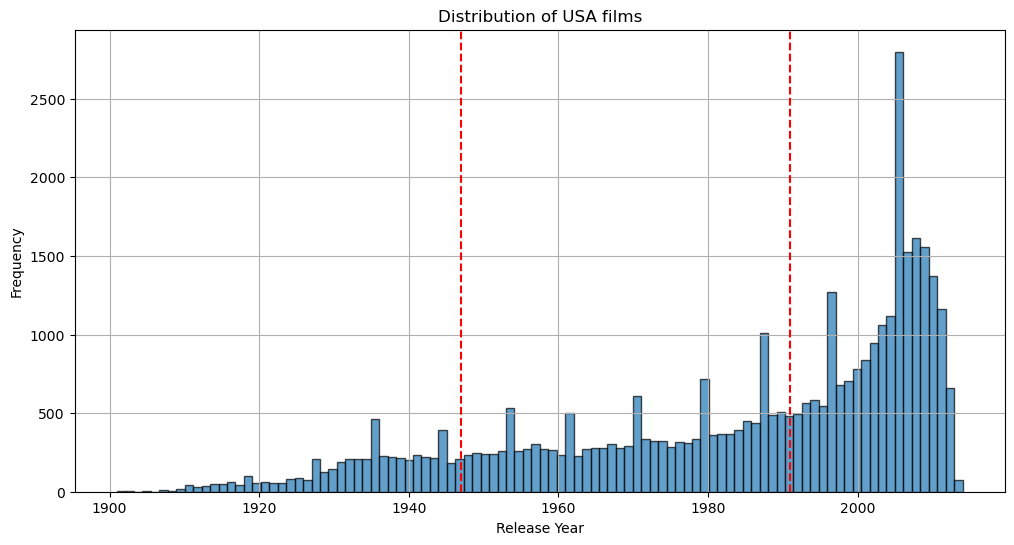

In [8]:
plt.figure(figsize=(12,6))
plt.hist(clean_df['release_date'], bins=100, edgecolor='black', alpha=0.7)
plt.title(f'Distribution of USA films')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
# draw red on the cold war period
plt.axvline(x=1947, color='red', linestyle='--')
plt.axvline(x=1991, color='red', linestyle='--')
plt.grid(True)
plt.show()

In [9]:
# movie_name = "First Blood"
movie_name = "From Russia with Love"
# movie_name = "Oshibka rezidenta"
movie = clean_df[clean_df['name'] == movie_name]
print(movie['plot_summary'].iloc[0])
print(movie['release_date'].iloc[0])

# Prompt:
# Here is a movie plot. You first need to identify if it can be identified to the Eastern or Western bloc during the Cold War. If yes come up with the character or group of character impersonating the Western and Eastern bloc and their values.
# Your output needs to be parsable with the first line being the first character followed by it's characteristics each comma separated.
# Second line on the second character.
# Then the theme of the movies and keywords comma separated.
# Then Cold war side belonging either Easter, Western or None.
# Then Western bloc represensation comma separated main values and characteristics 
# Then Eastern bloc representation


SPECTRE's expert planner Kronsteen devises a plot to steal a Lektor cryptographic device from the Soviets and sell it back to them while exacting revenge on Bond for killing their agent Dr. No. The Spectre Number 1 puts ex-SMERSH operative and Number 3 Rosa Klebb in charge of the mission. Klebb recruits Grant as an assassin, and Tatiana Romanova, a cipher clerk at the Soviet consulate in Istanbul, as an unwitting pawn, as Romanova thinks Klebb is still working for SMERSH. In London, M tells Bond – agent 007 and sometimes simply '007' – that Romanova has contacted their "Station 'T'" in Turkey, offering to defect with a Lektor, which MI6 and the CIA have been after for years – but Romanova said she will only defect to Bond, whose photo she has allegedly found in a Soviet intelligence file. Bond then flies to Istanbul, where he meets station head Ali Kerim Bey. 007 is followed from the airport by an unkempt man in glasses and by Red Grant. The next day, after Kerim Bey's office is bombed

In [10]:
import spacy
from textblob import TextBlob

# Load SpaCy model for NER and dependency parsing
nlp = spacy.load("en_core_web_sm")

# Movie plot summary to analyze
first_summary = "During World War II, the Allies face the Axis powers in a brutal conflict. The Allies, depicted as courageous and resilient, fight against tyranny, while the Axis is portrayed as ruthless and oppressive."

# Custom list of known belligerents for historical contexts
known_belligerents = ["Allies", "Axis"]

# Dictionary to store portrayals
belligerents = {key: {"descriptions": [], "sentiment": 0} for key in known_belligerents}

# Process the text
doc = nlp(first_summary)

# Analyze sentences for descriptions and sentiment
for sent in doc.sents:
    for belligerent in known_belligerents:
        if belligerent in sent.text:
            # Sentiment analysis
            blob = TextBlob(sent.text)
            belligerents[belligerent]["sentiment"] += blob.sentiment.polarity
            
            # Extract descriptive words related to the belligerent
            for token in sent:
                if token.dep_ in ["amod", "acomp", "attr"]:
                    belligerents[belligerent]["descriptions"].append(token.text)

# Display results
for belligerent, info in belligerents.items():
    descriptions = ", ".join(info["descriptions"])
    sentiment = "Positive" if info["sentiment"] > 0 else "Negative" if info["sentiment"] < 0 else "Neutral"
    print(f"{belligerent} portrayal:\n- Descriptions: {descriptions}\n- Sentiment: {sentiment}")

Allies portrayal:
- Descriptions: brutal, courageous, ruthless
- Sentiment: Negative
Axis portrayal:
- Descriptions: brutal, courageous, ruthless
- Sentiment: Negative
